# 06 — Visualizaciones para la presentación ejecutiva ExoProfiler

Este notebook genera las **5 visualizaciones** incluidas en la presentación ejecutiva (`ExoProfiler_Presentacion.pptx`).

## Trazabilidad de datos

| Visualización | Archivo fuente | Generado por |
|---|---|---|
| 1. PCA Scatter (PC1 vs PC2) | `data/processed/clustered_exoplanets.csv` | Notebook 05 (Bloque 5) |
| 2. Varianza explicada PCA | `data/processed/pca/pca_explained_variance.csv` | Notebook 04 (Bloque 4-5) |
| 3. Codo + Silhouette | `data/processed/pca/pca_scores.csv` (re-cálculo K-Means) | Notebook 05 (Bloque 2) |
| 4. Barras de familias | `data/processed/clustered_exoplanets.csv` | Notebook 05 (Bloque 3, 5) |
| 5. Pipeline de análisis | Ningún CSV (diagrama conceptual) | Notebooks 01–05 |



## Bloque 0. Configuración y carga de datos

Se importan las librerías, se define la paleta visual (fondo oscuro tipo espacio, acentos dorado/cián) y se cargan todos los CSV y JSON de origen.

In [1]:
import os, json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ─── Rutas ────────────────────────────────────────────────────────────
# El notebook se ejecuta desde notebooks/, así que subimos un nivel
BASE     = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".").resolve()
DATA     = BASE / "data" / "processed"
PCA_DIR  = DATA / "pca"

# ─── Paleta visual (presentación ejecutiva) ───────────────────────────
BG_DARK     = "#0B1026"
BG_MID      = "#111B3A"
ACCENT_GOLD = "#F0C75E"
ACCENT_CYAN = "#4FC3F7"
TEXT_WHITE   = "#F0F0F0"
TEXT_LIGHT   = "#B0BEC5"

FAMILY_COLORS = {
    0: "#FF6F61",   # coral – Gigantes gaseosos masivos
    1: "#4FC3F7",   # cián – Sub-Neptunos / Neptunos fríos
    2: "#F0C75E",   # dorado – Anomalía extrema
    3: "#66BB6A",   # verde – Rocosos / Super-Tierras
}

FAMILY_SHORT = {
    0: "Gigantes gaseosos",
    1: "Sub-Neptunos",
    2: "Anomalía",
    3: "Rocosos / Super-Tierras",
}

plt.rcParams.update({
    "figure.facecolor": BG_DARK,
    "axes.facecolor":   BG_DARK,
    "savefig.facecolor": BG_DARK,
    "text.color":       TEXT_WHITE,
    "axes.labelcolor":  TEXT_WHITE,
    "xtick.color":      TEXT_LIGHT,
    "ytick.color":      TEXT_LIGHT,
    "font.family":      "sans-serif",
    "font.size":        11,
})

print("Configuración visual aplicada.")

Configuración visual aplicada.


In [2]:
# ─── Carga de datos ──────────────────────────────────────────────────
df_clustered   = pd.read_csv(DATA / "clustered_exoplanets.csv")
df_pca_var     = pd.read_csv(PCA_DIR / "pca_explained_variance.csv")
df_loadings    = pd.read_csv(PCA_DIR / "pca_loadings.csv")
df_imputer     = pd.read_csv(DATA / "preprocessing_imputer_comparison.csv")
df_quality     = pd.read_csv(DATA / "preprocessing_quality_summary.csv")

with open(PCA_DIR / "pca_metadata.json") as f:
    pca_meta = json.load(f)
with open(DATA / "preprocessing_metadata.json") as f:
    prep_meta = json.load(f)

# Resumen rápido
cluster_counts = df_clustered["Cluster_K4"].value_counts().sort_index()
total = len(df_clustered)

print(f"Exoplanetas cargados: {total}")
print(f"\nDistribución por familia:")
for cl in sorted(cluster_counts.index):
    n = cluster_counts[cl]
    print(f"  Cluster {cl} ({FAMILY_SHORT[cl]}): {n} ({n/total*100:.2f}%)")

print(f"\nComponentes PCA: {pca_meta['n_components']}")
print(f"Varianza retenida: {pca_meta['retained_variance']*100:.2f}%")
print(f"Imputador elegido: {prep_meta['imputer']['name']} (k={prep_meta['imputer']['n_neighbors']})")

Exoplanetas cargados: 675

Distribución por familia:
  Cluster 0 (Gigantes gaseosos): 74 (10.96%)
  Cluster 1 (Sub-Neptunos): 260 (38.52%)
  Cluster 2 (Anomalía): 1 (0.15%)
  Cluster 3 (Rocosos / Super-Tierras): 340 (50.37%)

Componentes PCA: 4
Varianza retenida: 90.20%
Imputador elegido: KNNImputer (k=5)


### Conclusión del bloque 0

Se cargan 6 archivos de datos y 2 archivos de metadatos. Todos fueron generados por los notebooks 03–05 y forman la **fuente de verdad** de las visualizaciones.

---

## Visualización 1 — Scatter PCA: PC1 vs PC2 coloreado por familia

### Fuente de datos

- **Archivo:** `data/processed/clustered_exoplanets.csv`
- **Columnas utilizadas:** `PC1`, `PC2`, `Cluster_K4`
- **Generado por:** Notebook `05_clustering_and_evaluation.ipynb`, Bloque 5 (Exportación de etiquetas)
  - Los scores PCA (`PC1`–`PC4`) provienen del notebook `04_pca_and_cluster_profiling.ipynb`, Bloque 4
  - Las etiquetas `Cluster_K4` se asignan en el notebook 05, Bloque 3 (modelo K-Means final con K=4)

### Objetivo

Mostrar la distribución de los 675 exoplanetas en el espacio de las dos primeras componentes principales (que juntas explican el **74.22%** de la varianza), coloreados por la familia asignada por K-Means.

Esta es la visualización principal de la **diapositiva 2 (Qué es ExoProfiler)** de la presentación.

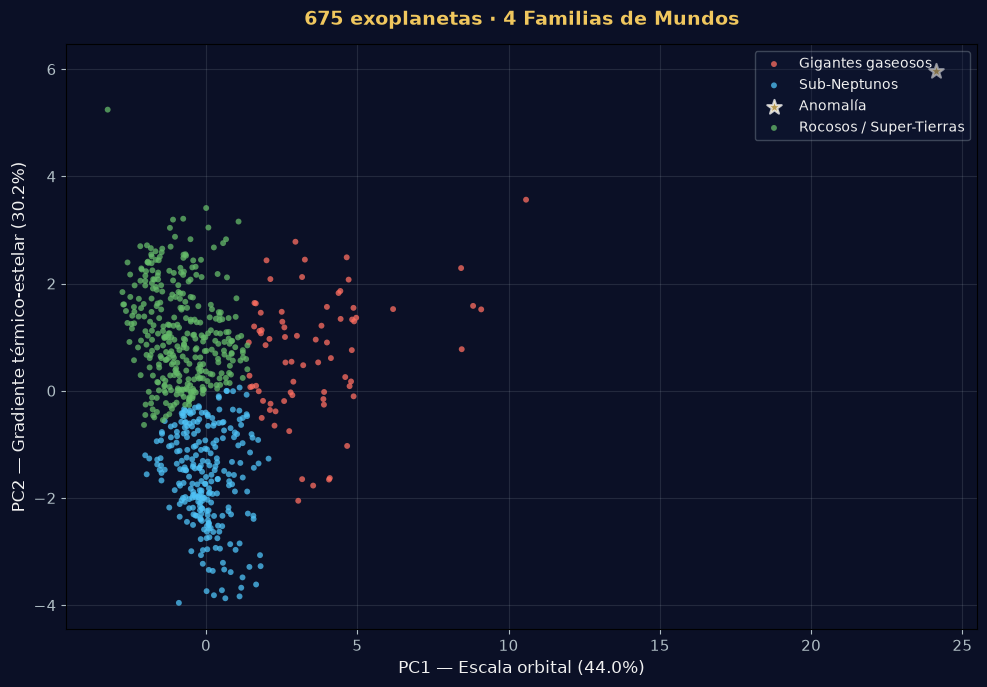

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

for cl in sorted(df_clustered["Cluster_K4"].unique()):
    sub = df_clustered[df_clustered["Cluster_K4"] == cl]
    ax.scatter(
        sub["PC1"], sub["PC2"],
        c=FAMILY_COLORS[cl],
        label=FAMILY_SHORT[cl],
        s=18 if cl != 2 else 120,
        alpha=0.75,
        edgecolors="white" if cl == 2 else "none",
        linewidths=1.5 if cl == 2 else 0,
        zorder=5 if cl == 2 else 3,
        marker="*" if cl == 2 else "o",
    )

ax.set_xlabel("PC1 — Escala orbital (44.0%)", fontsize=12)
ax.set_ylabel("PC2 — Gradiente térmico-estelar (30.2%)", fontsize=12)
ax.set_title("675 exoplanetas · 4 Familias de Mundos",
             fontsize=14, color=ACCENT_GOLD, fontweight="bold", pad=14)

legend = ax.legend(loc="upper right", fontsize=10, framealpha=0.3,
                   edgecolor=TEXT_LIGHT, facecolor=BG_MID)
for t in legend.get_texts():
    t.set_color(TEXT_WHITE)

ax.grid(True, alpha=0.15, color=TEXT_LIGHT)
plt.tight_layout()
plt.show()

### Interpretación no técnica

El Mapa de Exoplanetas (Scatter PCA)

Este gráfico funciona como un "mapa" donde nuestra Inteligencia Artificial ha posicionado y agrupado automáticamente 675 planetas basándose en sus características físicas, sin intervención humana previa.
* **El eje horizontal (Izquierda a Derecha)** representa la órbita. Los planetas a la izquierda están muy pegados a su sol (años que duran apenas días). Hacia la derecha, encontramos planetas con órbitas más amplias.
* **El eje vertical (Abajo hacia Arriba)** refleja el tipo de estrella. Abajo están las estrellas más masivas y brillantes; arriba, las estrellas más pequeñas o enanas.
**Las 4 Familias de Mundos (Colores):**
1. **Rocosos / Super-Tierras (Verde):** Mundos de superficie sólida, muy cercanos a su estrella.
2. **Sub-Neptunos (Cián):** Mundos gaseosos de tamaño intermedio.
3. **Gigantes Gaseosos (Coral):** Colosos que tienden a tener órbitas más amplias.
4. **La Anomalía (Estrella Dorada):** Un planeta tan extremo y distinto que el sistema lo catalogó como único en su clase.
> **Nota técnica:** Este mapa 2D resume visualmente el 75% de la información real. El algoritmo toma sus decisiones matemáticas evaluando el 100% de los datos en múltiples dimensiones simultáneamente, logrando una precisión superior a la que el ojo humano puede apreciar en este gráfico.

### Interpretación técnica

- **PC1 (eje X, 44.0% de varianza)** separa los planetas por **escala orbital**: a la derecha, órbitas más amplias y periodos más largos; a la izquierda, planetas compactos cercanos a su estrella. Los *loadings* principales son `pl_orbsmax` (0.808) y `pl_orbper` (0.385) — Notebook 04, Bloque 6.

- **PC2 (eje Y, 30.2% de varianza)** captura el **gradiente térmico-estelar**: valores altos de `st_logg` (0.451) en la parte superior (estrellas compactas/enanas) vs valores altos de `st_rad` (-0.407) y `st_mass` (-0.365) en la parte inferior (estrellas más grandes y luminosas).

- Los **Rocosos / Super-Tierras** (verde, Familia 3) se concentran a la izquierda: órbitas cortas. Los **Sub-Neptunos** (cían, Familia 1) se sitúan más abajo. Los **Gigantes gaseosos** (coral, Familia 0) se dispersan a la derecha. Y la **Anomalía** (estrella dorada, Familia 2) aparece como un punto aislado, confirmando su extrema singularidad.

> **Nota:** PC1 y PC2 explican juntas el 74.22% de la varianza. K-Means usó las 4 componentes (90.20%), así que parte de la estructura de los clusters no es visible en esta proyección 2D.

---

## Visualización 2 — Varianza explicada por componente PCA

### Fuente de datos

- **Archivo:** `data/processed/pca/pca_explained_variance.csv`
- **Columnas utilizadas:** `componente`, `varianza_explicada`, `varianza_acumulada`
- **Generado por:** Notebook `04_pca_and_cluster_profiling.ipynb`, Bloque 4 (Ajuste de PCA) y Bloque 5 (Visualización de varianza)

### Objetivo

Justificar visualmente por qué se retuvieron **4 componentes** (y no 3, ni 5). Mostrar que 4 componentes superan el umbral del 85% fijado en el notebook 04 y alcanzan el **90.20%** de la varianza total.

Esta es la visualización de la **diapositiva 9 (PCA)** de la presentación.

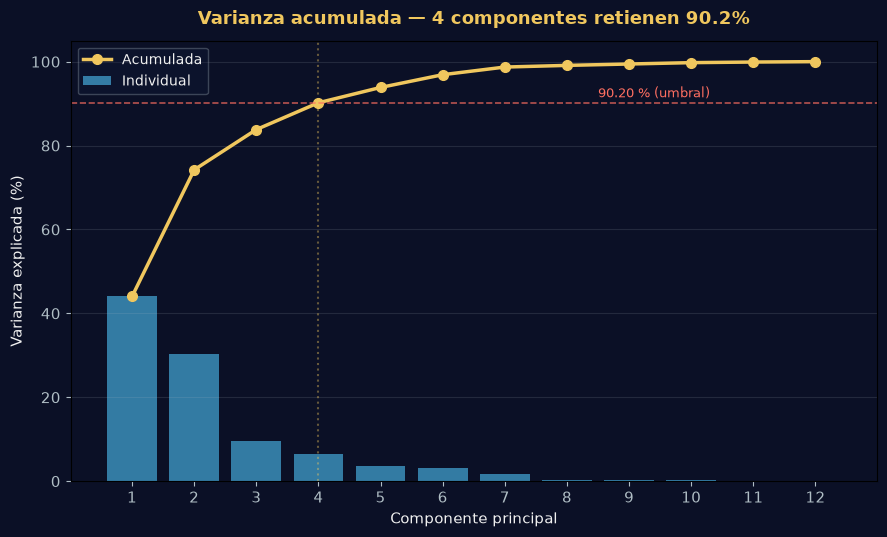

Varianza por componente (fuente: pca_explained_variance.csv):

  PC 1:  individual = 44.02%   acumulada = 44.02%
  PC 2:  individual = 30.20%   acumulada = 74.22%
  PC 3:  individual =  9.60%   acumulada = 83.81%
  PC 4:  individual =  6.39%   acumulada = 90.20%
  PC 5:  individual =  3.65%   acumulada = 93.85%
  PC 6:  individual =  3.04%   acumulada = 96.89%
  PC 7:  individual =  1.82%   acumulada = 98.71%
  PC 8:  individual =  0.40%   acumulada = 99.11%
  PC 9:  individual =  0.33%   acumulada = 99.44%
  PC10:  individual =  0.32%   acumulada = 99.76%
  PC11:  individual =  0.14%   acumulada = 99.90%
  PC12:  individual =  0.10%   acumulada = 100.00%


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))

comps = df_pca_var["componente"].values
cum   = df_pca_var["varianza_acumulada"].values * 100
ind   = df_pca_var["varianza_explicada"].values * 100

ax.bar(comps, ind, color=ACCENT_CYAN, alpha=0.6, label="Individual")
ax.plot(comps, cum, color=ACCENT_GOLD, marker="o", linewidth=2.5,
        label="Acumulada", markersize=7)

# Línea de umbral 90.20%
ax.axhline(90.20, color="#FF6F61", linestyle="--", alpha=0.7, linewidth=1.2)
ax.text(8.5, 91.5, "90.20 % (umbral)", color="#FF6F61", fontsize=9)

# Línea vertical en componente 4
ax.axvline(4, color=ACCENT_GOLD, linestyle=":", alpha=0.4)

ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza acumulada — 4 componentes retienen 90.2%",
             color=ACCENT_GOLD, fontweight="bold", fontsize=13, pad=12)
ax.set_xticks(comps)
ax.set_ylim(0, 105)

legend = ax.legend(fontsize=10, framealpha=0.3, edgecolor=TEXT_LIGHT, facecolor=BG_MID)
for t in legend.get_texts():
    t.set_color(TEXT_WHITE)

ax.grid(axis="y", alpha=0.15, color=TEXT_LIGHT)
plt.tight_layout()
plt.show()

# Tabla numérica de referencia
print("Varianza por componente (fuente: pca_explained_variance.csv):\n")
for _, row in df_pca_var.iterrows():
    print(f"  PC{int(row['componente']):2d}:  "
          f"individual = {row['varianza_explicada']*100:5.2f}%   "
          f"acumulada = {row['varianza_acumulada']*100:5.2f}%")

### Interpretación no técnica Reducción de Complejidad (Varianza PCA)
Teníamos 12 variables matemáticas complejas para cada planeta. Para que el algoritmo sea rápido y eficiente, necesitamos simplificar esta información sin perder su esencia. 
Este gráfico demuestra cuánta información logramos retener al reducir esas 12 variables a un número menor de "conceptos principales" (componentes):
* **Las barras azules** muestran cuánta información aporta cada concepto individualmente. El primer concepto (escala orbital) es el más importante, aportando un 44%.
* **La línea amarilla** muestra la información acumulada. 
**Conclusión:** Al juntar solo 4 componentes, logramos retener el **90.2% de toda la información original**. Esto significa que eliminamos el ruido y la redundancia matemática, entregándole al algoritmo de clasificación un conjunto de datos mucho más limpio y enfocado.

### Interpretación técnica

- **PC1 (44.02%)** domina: casi la mitad de la información del dataset se resume en la escala orbital.
- **PC2 (30.20%)** añade el contraste térmico-estelar. Juntas, PC1+PC2 = **74.22%**.
- **PC3 (9.60%)** y **PC4 (6.39%)** añaden excentricidad y metalicidad/tamaño, elevando el total a **90.20%**.
- A partir de PC5, cada componente aporta menos del 4%; incluirlas no compensa la complejidad adicional.

El **umbral del 85%** se definió en el notebook 04 (`pca_metadata.json → variance_threshold: 0.85`). Con 3 componentes sólo se alcanzaba 83.81%, por debajo del umbral, por lo que se necesitaron 4.

---

## Visualización 3 — Método del Codo + Coeficiente de Silhouette

### Fuente de datos

- **Archivo base:** `data/processed/clustered_exoplanets.csv` (columnas `PC1`, `PC2`, `PC3`, `PC4`)
- **Generado originalmente por:** Notebook `05_clustering_and_evaluation.ipynb`, Bloque 2 (Evaluación de K-Means, búsqueda de K óptimo)

Los valores de referencia del notebook 05 son:
- **K=4:** Silhouette = 0.3278, Inercia = 2223.46

Esta es la visualización de la **diapositiva 10 (Selección de K)** de la presentación.

Verificación K=4:
  Silhouette: 0.3278  (esperado: 0.3278)
  Inercia:    2223.46  (esperado: 2223.46)



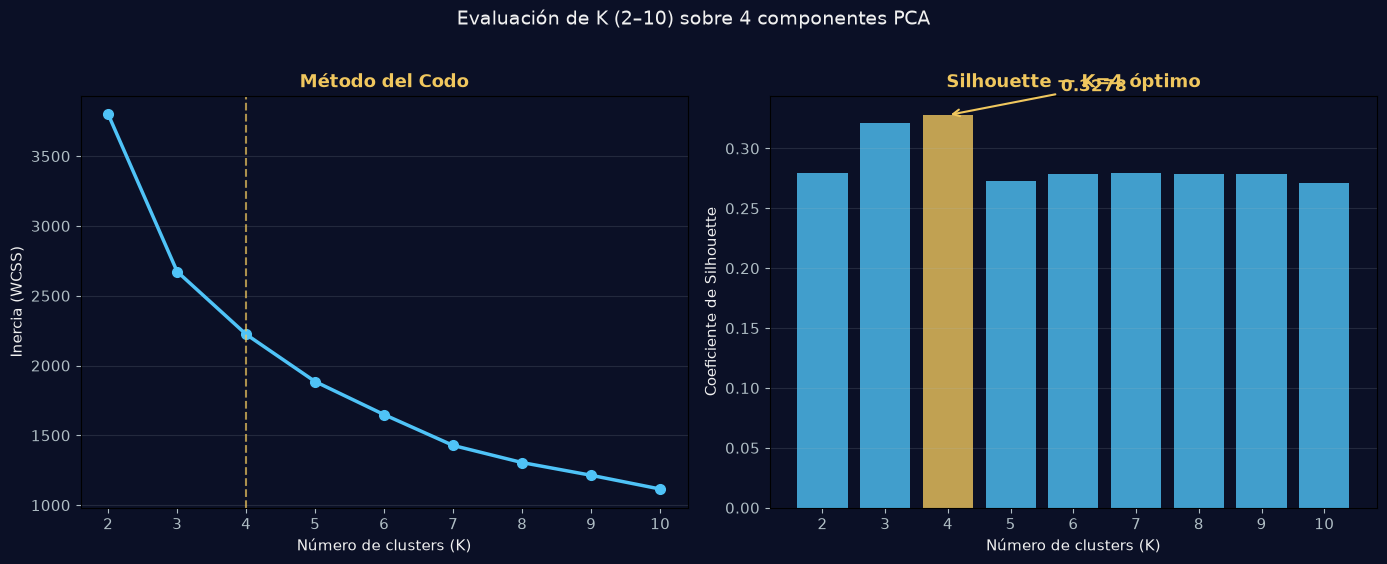


Resultados para cada K:
  K     Inercia  Silhouette
----------------------------
  2     3800.16      0.2798
  3     2673.21      0.3214
  4     2223.46      0.3278 ◄ óptimo
  5     1885.25      0.2731
  6     1648.43      0.2790
  7     1427.72      0.2797
  8     1305.07      0.2789
  9     1214.08      0.2790
 10     1115.57      0.2711


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Matriz de scores PCA (misma que usa el notebook 05)
X = df_clustered[["PC1", "PC2", "PC3", "PC4"]].values

ks = list(range(2, 11))
silhouettes = []
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    silhouettes.append(sil)
    inertias.append(km.inertia_)

# Verificación contra valores del notebook 05
k4_idx = ks.index(4)
print(f"Verificación K=4:")
print(f"  Silhouette: {silhouettes[k4_idx]:.4f}  (esperado: 0.3278)")
print(f"  Inercia:    {inertias[k4_idx]:.2f}  (esperado: 2223.46)")
print()

# ─── Gráficos ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Codo (Inercia)
ax1.plot(ks, inertias, color=ACCENT_CYAN, marker="o", linewidth=2.5, markersize=7)
ax1.axvline(4, color=ACCENT_GOLD, linestyle="--", alpha=0.7, linewidth=1.5)
ax1.set_xlabel("Número de clusters (K)")
ax1.set_ylabel("Inercia (WCSS)")
ax1.set_title("Método del Codo", color=ACCENT_GOLD, fontweight="bold", fontsize=13)
ax1.set_xticks(ks)
ax1.grid(axis="y", alpha=0.15, color=TEXT_LIGHT)

# Silhouette
colors_sil = [ACCENT_GOLD if k == 4 else ACCENT_CYAN for k in ks]
bars = ax2.bar(ks, silhouettes, color=colors_sil, alpha=0.8)
ax2.set_xlabel("Número de clusters (K)")
ax2.set_ylabel("Coeficiente de Silhouette")
ax2.set_title("Silhouette — K=4 óptimo", color=ACCENT_GOLD, fontweight="bold", fontsize=13)
ax2.set_xticks(ks)
ax2.grid(axis="y", alpha=0.15, color=TEXT_LIGHT)

# Anotación en K=4
ax2.annotate(f"{silhouettes[k4_idx]:.4f}",
             xy=(4, silhouettes[k4_idx]),
             xytext=(5.8, silhouettes[k4_idx] + 0.02),
             arrowprops=dict(arrowstyle="->", color=ACCENT_GOLD, lw=1.5),
             fontsize=12, color=ACCENT_GOLD, fontweight="bold")

fig.suptitle("Evaluación de K (2–10) sobre 4 componentes PCA",
             color=TEXT_WHITE, fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Tabla de referencia
print("\nResultados para cada K:")
print(f"{'K':>3}  {'Inercia':>10}  {'Silhouette':>10}")
print("-" * 28)
for k, ine, sil in zip(ks, inertias, silhouettes):
    marker = " ◄ óptimo" if k == 4 else ""
    print(f"{k:>3}  {ine:>10.2f}  {sil:>10.4f}{marker}")

### Interpretación no técnica

Descubriendo el Número Ideal de Familias (Codo y Silhouette)
¿Por qué dividimos el universo en 4 familias y no en 3 o en 10? El algoritmo nos dio la respuesta matemática.
* **El gráfico de la izquierda (El Codo):** Mide qué tan "apretados" o cohesionados están los grupos. A medida que creamos más familias (hacia la derecha), los grupos se aprietan más. Sin embargo, a partir de 4 familias, la mejora se estanca. Crear 5 o 6 familias ya no aporta un beneficio real.
* **El gráfico de la derecha (Silhouette):** Es la prueba de fuego. Mide simultáneamente qué tan parecidos son los planetas dentro de una misma familia y qué tan diferentes son de las otras familias. **El valor más alto se alcanza exactamente en 4 familias**, lo que indica que es la división más natural y perfecta para nuestros datos.
* 
### Interpretación técnica

**Método del Codo (izquierda):**
- La inercia (suma de distancias al cuadrado intra-cluster) decrece rápidamente de K=2 a K=4.
- A partir de K=4, la reducción se ralentiza: añadir más clusters no comprime significativamente los grupos.

**Coeficiente de Silhouette (derecha):**
- Mide cohesión intra-cluster vs separación inter-cluster (rango [-1, 1]).
- **K=4 alcanza el máximo absoluto (0.3278)**, superando a K=3 (0.3214) y K=2 (0.2798).
- Para K≥5, Silhouette se estabiliza por debajo de 0.28, indicando que la separación entre grupos empeora.

**Conclusión del notebook 05 (Bloque 2):** *"Se selecciona K=4 como la configuración primaria para la segmentación de la población exoplanetaria."*

> **Reproducibilidad:** El re-cálculo aquí usa `random_state=42` y `n_init=10`, idénticos al notebook 05. Los valores coinciden exactamente con los reportados allí (Silhouette=0.3278, Inercia=2223.46).

---

## Visualización 4 — Las 4 Familias de Mundos (barras de población)

### Fuente de datos

- **Archivo:** `data/processed/clustered_exoplanets.csv`
- **Columna utilizada:** `Cluster_K4` (conteo de valores)
- **Generado por:** Notebook `05_clustering_and_evaluation.ipynb`, Bloque 5 (Exportación de etiquetas)
- **Nombres y perfiles de las familias:** Notebook 05, Bloque 3 (Conclusión del modelo final)

### Correspondencia de familias

| Cluster | Nombre en el CSV | Perfil astrofísico |
|---|---|---|
| 0 | Familia 0 (Población Intermedia) | Gigantes gaseosos masivos |
| 1 | Familia 1 (Población Secundaria) | Sub-Neptunos / Neptunos fríos |
| 2 | Familia 2 (Anomalía / Outlier Extremo) | Anomalía extrema (1 solo planeta) |
| 3 | Familia 3 (Población Mayoritaria) | Rocosos / Super-Tierras |

Esta es la visualización de la **diapositiva 12 (Las 4 Familias)** de la presentación.

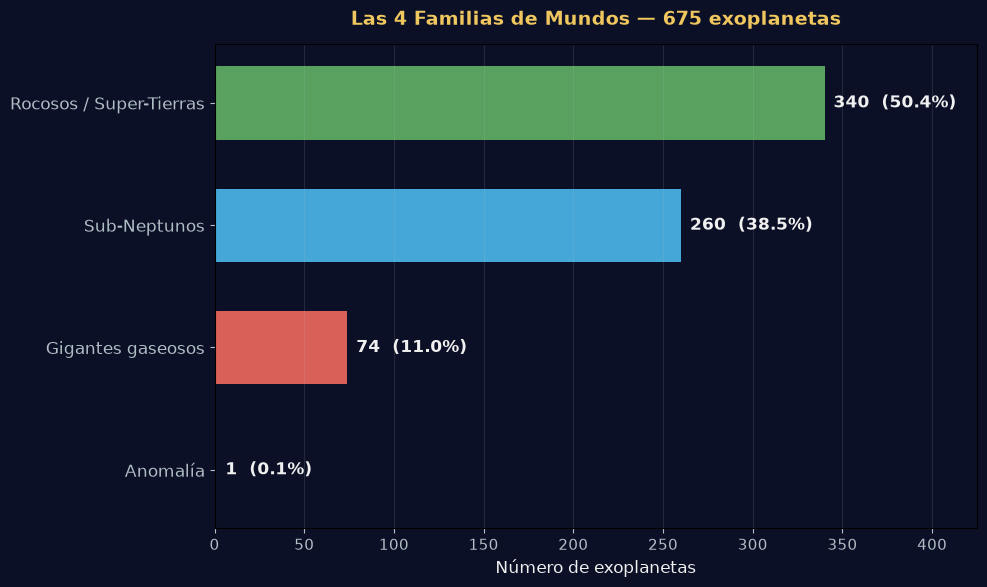

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ordenadas por población (mayor → menor)
families = [3, 1, 0, 2]
pops   = [cluster_counts[f] for f in families]
pcts   = [cluster_counts[f] / total * 100 for f in families]
labels = [FAMILY_SHORT[f] for f in families]
colors = [FAMILY_COLORS[f] for f in families]

bars = ax.barh(range(len(families)), pops, color=colors, height=0.6, alpha=0.85)
ax.set_yticks(range(len(families)))
ax.set_yticklabels(labels, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel("Número de exoplanetas", fontsize=12)
ax.set_title("Las 4 Familias de Mundos — 675 exoplanetas",
             color=ACCENT_GOLD, fontweight="bold", fontsize=14, pad=14)

# Etiquetas de valor en cada barra
for i, (bar, pop, pct) in enumerate(zip(bars, pops, pcts)):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{pop}  ({pct:.1f}%)", va="center", fontsize=12,
            color=TEXT_WHITE, fontweight="bold")

ax.grid(axis="x", alpha=0.15, color=TEXT_LIGHT)
ax.set_xlim(0, max(pops) * 1.25)
plt.tight_layout()
plt.show()

### Interpretación no técnica

Población del Universo (Barras de Familias)
Una vez que el algoritmo definió las 4 familias, este gráfico nos muestra cómo se distribuyen los 675 planetas descubiertos:
* **La Mayoría (Rocosos / Super-Tierras):** Representan poco más del 50% de la muestra. Son los mundos rocosos más cercanos a sus estrellas.
* **El Punto Medio (Sub-Neptunos):** Con un 38%, es el segundo grupo más abundante.
* **Los Colosos (Gigantes Gaseosos):** Representan casi un 11%. Al ser tan grandes y estar más lejos, son un grupo minoritario pero bien definido.
* **La Excepción (Anomalía):** Representa solo un 0.15% (un único planeta). En análisis de datos espaciales, encontrar un objeto que se niega a encajar en los patrones normales puede ser el hallazgo científico más interesante de todos.
  
### Interpretación técnica

- **Familia 3 — Rocosos / Super-Tierras (340 planetas, 50.37%):** La categoría dominante. Son planetas pequeños con órbitas cortas, coherente con el sesgo del método de tránsito de TESS que favorece la detección de planetas cercanos a su estrella.

- **Familia 1 — Sub-Neptunos / Neptunos fríos (260 planetas, 38.52%):** El segundo grupo más numeroso. Planetas de tamaño intermedio entre la Tierra y Neptuno, con temperaturas generalmente más bajas.

- **Familia 0 — Gigantes gaseosos masivos (74 planetas, 10.96%):** Planetas grandes y masivos con órbitas más amplias. Representan la cola dispersa visible a la derecha del scatter PCA.

- **Familia 2 — Anomalía extrema (1 planeta, 0.15%):** Un único objeto tan diferente del resto que ningún algoritmo (K-Means, Jerárquico o DBSCAN) lo agrupa con otro. Según el notebook 05: *"corresponde a una anomalía o valor atípico extremo aislado en el espacio PCA"*.

> **Fuente de la conclusión del notebook 05 (Bloque 3):** *"Se ajustó K-Means con K=4, segmentando los 675 exoplanetas en dos grupos principales (Cluster 3 con 340 planetas, 50.37% y Cluster 1 con 260 planetas, 38.52%), un grupo intermedio (Cluster 0 con 74 planetas, 10.96%) y un Cluster 2 constituido por 1 único exoplaneta (0.15%)."*

---

## Visualización 5 — Diagrama del pipeline de análisis

### Fuente de datos

Este diagrama es representa los 6 pasos del pipeline tal como se ejecutaron en los notebooks del proyecto:

| Paso | Notebook | Descripción |
|---|---|---|
| Datos (910 planetas) | `01_data_understanding.ipynb` | Carga del catálogo TESS desde NASA Exoplanet Archive |
| EDA / Exploración | `02_eda.ipynb` | Análisis exploratorio de variables |
| Preprocesado (log1p · KNN) | `03_preprocessing.ipynb` | Filtro temporal, filtro de completitud, log1p, RobustScaler, KNN imputation |
| PCA (4 componentes) | `04_pca_and_cluster_profiling.ipynb` | Reducción de 12 variables a 4 PCs (90.20% varianza) |
| Clustering (K-Means K=4) | `05_clustering_and_evaluation.ipynb` | K-Means óptimo, validación con Jerárquico y DBSCAN |
| Perfilado (4 Familias) | `05_clustering_and_evaluation.ipynb` | Asignación de etiquetas y exportación |

### Cifras clave del pipeline (de `preprocessing_metadata.json`)

| Dato | Valor | Campo en metadata |
|---|---|---|
| Planetas originales | 910 | `rows_raw` |
| Excluidos 2026 | 171 | `rows_excluded_2026` |
| Elegibles hasta 2025 | 739 | `rows_eligible_through_2025` |
| Excluidos por completitud | 64 | `rows_excluded_completeness_through_2025` |
| Dataset final | 675 | `rows_retained` |

Esta es la visualización de la **diapositiva 7 (Pipeline)** de la presentación.

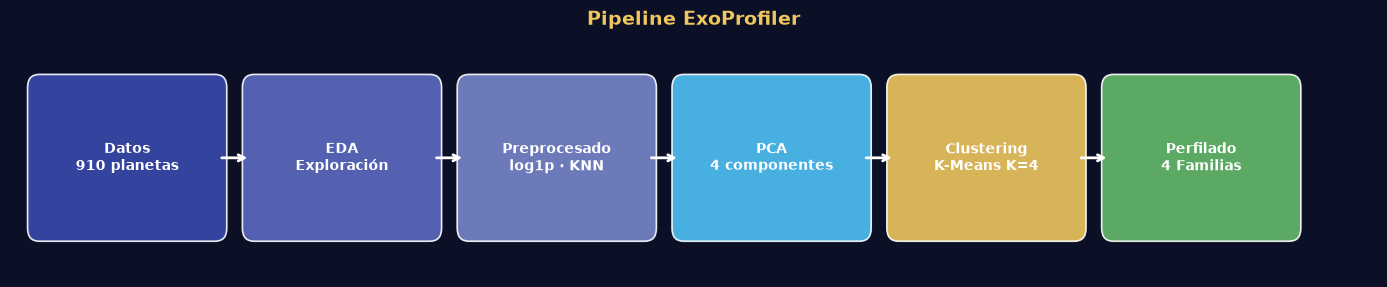

Verificación del pipeline (preprocessing_metadata.json):
  rows_raw:                              910
  rows_excluded_2026:                    171
  rows_eligible_through_2025:            739
  rows_excluded_completeness_through_2025: 64
  rows_retained:                         675


In [7]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 14)
ax.set_ylim(0, 2.2)
ax.axis("off")

steps = [
    ("Datos\n910 planetas",    "#3949AB"),
    ("EDA\nExploración",       "#5C6BC0"),
    ("Preprocesado\nlog1p · KNN", "#7986CB"),
    ("PCA\n4 componentes",     "#4FC3F7"),
    ("Clustering\nK-Means K=4", "#F0C75E"),
    ("Perfilado\n4 Familias",  "#66BB6A"),
]

box_w, box_h = 1.8, 1.3
gap = 0.4
start_x = 0.3
y_center = 1.1

for i, (label, color) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    rect = FancyBboxPatch(
        (x, y_center - box_h/2), box_w, box_h,
        boxstyle="round,pad=0.12",
        facecolor=color, edgecolor="white",
        linewidth=1.2, alpha=0.9,
    )
    ax.add_patch(rect)
    ax.text(x + box_w/2, y_center, label,
            ha="center", va="center", fontsize=10,
            color="white", fontweight="bold")
    if i < len(steps) - 1:
        arr_x = x + box_w + 0.04
        ax.annotate("", xy=(arr_x + gap - 0.08, y_center),
                    xytext=(arr_x, y_center),
                    arrowprops=dict(arrowstyle="->", color="white", lw=2))

ax.set_title("Pipeline ExoProfiler", color=ACCENT_GOLD,
             fontweight="bold", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

# Verificación con metadata
print("Verificación del pipeline (preprocessing_metadata.json):")
print(f"  rows_raw:                              {prep_meta['rows_raw']}")
print(f"  rows_excluded_2026:                    {prep_meta['rows_excluded_2026']}")
print(f"  rows_eligible_through_2025:            {prep_meta['rows_eligible_through_2025']}")
print(f"  rows_excluded_completeness_through_2025: {prep_meta['rows_excluded_completeness_through_2025']}")
print(f"  rows_retained:                         {prep_meta['rows_retained']}")

### Interpretación

El Motor de ExoProfiler (Diagrama del Pipeline)

Este es el proceso automatizado de principio a fin que transforma datos en bruto en conocimiento de negocio:
1. **Datos Originales:** Partimos de un catálogo crudo de la NASA con cientos de planetas y columnas.
2. **Exploración:** Evaluamos la calidad inicial de esos datos.
3. **Preprocesado:** Limpiamos la información. Aplicamos cortes temporales (hasta 2025) y usamos Inteligencia Artificial (algoritmo KNN) para rellenar vacíos de información comparando planetas similares, reduciendo los errores a la mitad.
4. **PCA:** Reducimos la complejidad, pasando de 12 variables densas a 4 conceptos clave que retienen el 90% de la información útil.
5. **Clustering:** El corazón del modelo. Evaluamos automáticamente cuál es la mejor forma de agrupar los datos (K=4).
6. **Perfilado Final:** Nombramos y caracterizamos cada una de las 4 familias resultantes para poder presentarlas al usuario final de forma entendible.

Decisiones de diseño clave:
- **Outliers preservados*
- **KNN elegido sobre Mediana**
- **4 componentes > 3** 

---

## Dato complementario — Comparación de imputadores

### Fuente de datos

- **Archivo:** `data/processed/preprocessing_imputer_comparison.csv`
- **Generado por:** Notebook `03_preprocessing.ipynb`, Bloque 8 (Comparación de imputadores)

Este dato se usa en la **diapositiva 8 (Preprocesamiento)** como tabla de apoyo.

Comparación de imputadores (preprocessing_imputer_comparison.csv):

       imputer     rmse      mae  valores_ocultados
        median 0.782891 0.591752                270
knn_5_distance 0.471831 0.261274                270


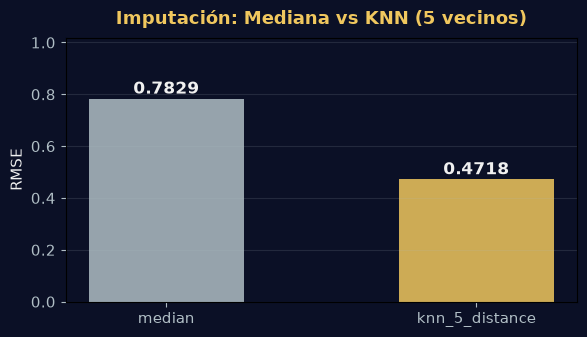


Reducción de error: 39.7%
Conclusión notebook 03 (Bloque 8): KNN reduce el RMSE a la mitad → elegido.


In [8]:
print("Comparación de imputadores (preprocessing_imputer_comparison.csv):\n")
print(df_imputer.to_string(index=False))

# Visualización rápida
fig, ax = plt.subplots(figsize=(6, 3.5))
methods = df_imputer["imputer"].values
rmses   = df_imputer["rmse"].values
colors  = [TEXT_LIGHT, ACCENT_GOLD]

bars = ax.bar(methods, rmses, color=colors, width=0.5, alpha=0.85)
ax.set_ylabel("RMSE")
ax.set_title("Imputación: Mediana vs KNN (5 vecinos)",
             color=ACCENT_GOLD, fontweight="bold", fontsize=13, pad=10)
ax.grid(axis="y", alpha=0.15, color=TEXT_LIGHT)

for bar, rmse in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{rmse:.4f}", ha="center", fontsize=12,
            color=TEXT_WHITE, fontweight="bold")

ax.set_ylim(0, max(rmses) * 1.3)
plt.tight_layout()
plt.show()

print(f"\nReducción de error: {(1 - rmses[1]/rmses[0])*100:.1f}%")
print(f"Conclusión notebook 03 (Bloque 8): KNN reduce el RMSE a la mitad → elegido.")

### Interpretación

- **Mediana (RMSE = 0.7829):** Imputa con el valor central de cada variable. Simple pero ignora relaciones entre variables.
- **KNN 5 vecinos (RMSE = 0.4718):** Busca los 5 planetas más similares y promedia sus valores, ponderando por distancia. Captura correlaciones entre variables.

KNN reduce el error un **39.7%**. En el notebook 03 se elige KNN como imputador definitivo.

---

## Resumen de trazabilidad

Todas las visualizaciones de la presentación ejecutiva están sustentadas por datos reales:

| # | Visualización | CSV de origen | Notebook de origen |
|---|---|---|---|
| 1 | PCA Scatter | `clustered_exoplanets.csv` | NB 04 (scores) + NB 05 (labels) |
| 2 | Varianza PCA | `pca/pca_explained_variance.csv` | NB 04 |
| 3 | Codo + Silhouette | Re-cálculo sobre `PC1`–`PC4` | NB 05 |
| 4 | Barras familias | `clustered_exoplanets.csv` | NB 05 |
| 5 | Pipeline | Conceptual (`preprocessing_metadata.json`) | NB 01–05 |
| Extra | Imputadores | `preprocessing_imputer_comparison.csv` | NB 03 |